Movie Rating Prediction



## 1. Dataset Description



In [32]:
from google.colab import files
uploaded = files.upload()   # click "Choose Files" and select "IMDb Movies India.csv"

Saving IMDb Movies India.csv to IMDb Movies India.csv


## 2. Library Installation



In [2]:
# Uncomment the line below if you need to install the libraries
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib

## 3. Import Required Libraries



In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Saving the model
import joblib

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Show all columns when printing DataFrames
pd.set_option("display.max_columns", None)

print("All libraries imported successfully.")

All libraries imported successfully.


## 4. Load the Dataset



In [4]:
# Path to the dataset (adjust if your folder structure differs)
DATA_PATH = "IMDb Movies India.csv"

# Load the dataset
df = pd.read_csv(DATA_PATH, encoding="latin1")

# Preview the first 5 rows
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


## 5. Explore the Dataset



### 5.1 Shape of the Dataset



In [5]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 15509 rows and 10 columns.


### 5.2 Data Types



In [6]:
df.dtypes

,0
Name,object
Year,object
Duration,object
Genre,object
Rating,float64
Votes,object
Director,object
Actor 1,object
Actor 2,object
Actor 3,object


### 5.3 Missing Values



In [7]:
df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


### 5.4 Statistical Summary



In [8]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


## 6. Data Cleaning



### 6.1 Handle Missing Values in the Target


In [9]:
# Drop rows where the target variable 'Rating' is missing
df = df.dropna(subset=["Rating"]).copy()

print(f"Dataset shape after dropping missing ratings: {df.shape}")

Dataset shape after dropping missing ratings: (7919, 10)


### 6.2 Clean the `Year` Column



In [10]:
# Extract 4-digit year from strings like '(2019)'
df["Year"] = df["Year"].astype(str).str.extract(r"(\d{4})")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Fill missing years with the median year
df["Year"] = df["Year"].fillna(df["Year"].median())
df["Year"] = df["Year"].astype(int)

df["Year"].head()

,Year
1,2019
3,2019
5,1997
6,2005
8,2012


### 6.3 Clean the `Duration` Column



In [11]:
# Extract the numeric part of '109 min' -> 109
df["Duration"] = df["Duration"].astype(str).str.extract(r"(\d+)")
df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce")

# Fill missing durations with the median duration
df["Duration"] = df["Duration"].fillna(df["Duration"].median())

df["Duration"].head()

,Duration
1,109.0
3,110.0
5,147.0
6,142.0
8,82.0


### 6.4 Clean the `Votes` Column



In [12]:
# Remove commas and convert to numeric
df["Votes"] = df["Votes"].astype(str).str.replace(",", "", regex=False)
df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")

# Fill missing votes with 0
df["Votes"] = df["Votes"].fillna(0).astype(int)

df["Votes"].head()

,Votes
1,8
3,35
5,827
6,1086
8,326


### 6.5 Handle Missing Values in Categorical Columns



In [13]:
categorical_cols = ["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

df[categorical_cols].isnull().sum()

,0
Genre,0
Director,0
Actor 1,0
Actor 2,0
Actor 3,0


### 6.6 Remove Duplicate Rows



In [14]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f"Removed {before - after} duplicate rows.")
print(f"Final cleaned dataset shape: {df.shape}")

Removed 0 duplicate rows.
Final cleaned dataset shape: (7919, 10)


### 6.7 Final Check


In [15]:
print(df[["Year", "Duration", "Votes", "Rating"]].dtypes)
print()
print(df.isnull().sum())

Year          int64
Duration    float64
Votes         int64
Rating      float64
dtype: object

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


## 7. Exploratory Data Analysis (EDA)



### 7.1 Distribution of Movie Ratings



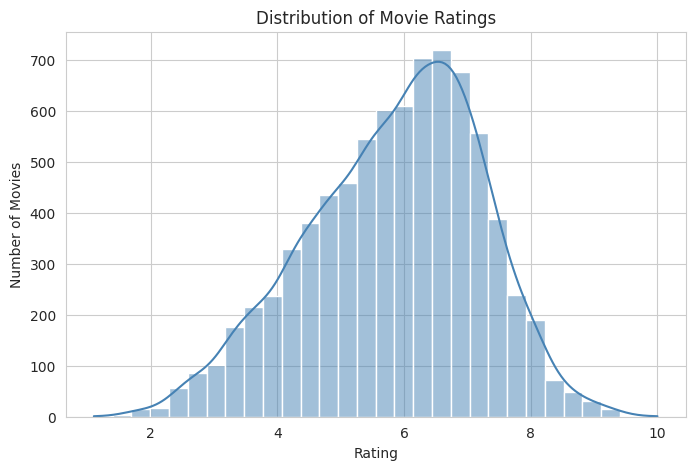

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Rating"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.show()

### 7.2 Movies by Genre



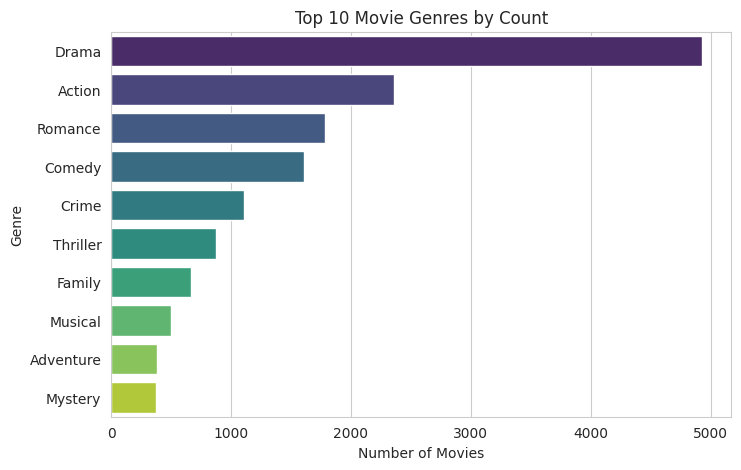

In [17]:
# Split comma-separated genres and count each individually
all_genres = df["Genre"].str.split(", ").explode()
top_genres = all_genres.value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index,
            palette="viridis", legend=False)
plt.title("Top 10 Movie Genres by Count")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

### 7.3 Rating vs Votes



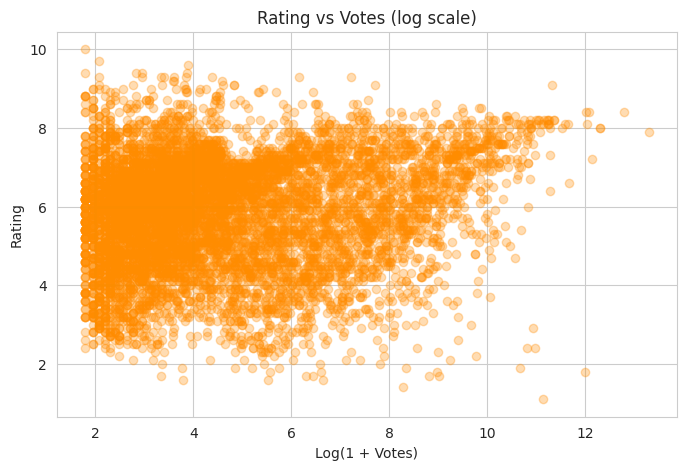

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(np.log1p(df["Votes"]), df["Rating"], alpha=0.3, color="darkorange")
plt.title("Rating vs Votes (log scale)")
plt.xlabel("Log(1 + Votes)")
plt.ylabel("Rating")
plt.show()

### 7.4 Rating vs Year



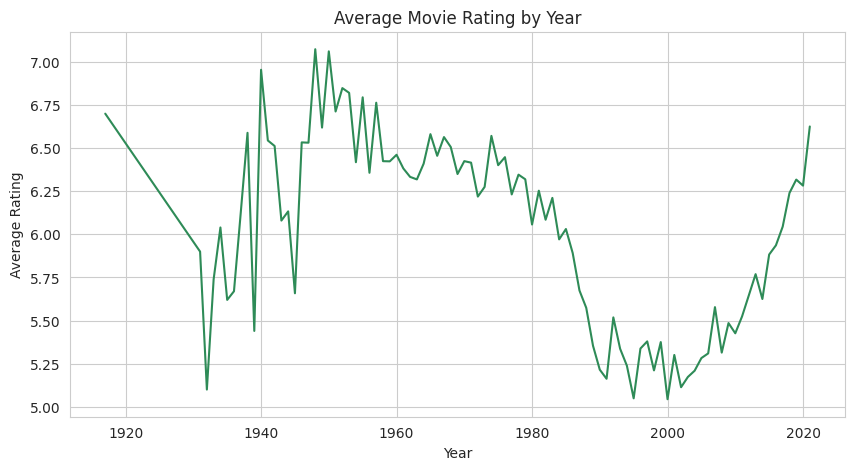

In [19]:
avg_rating_by_year = df.groupby("Year")["Rating"].mean()

plt.figure(figsize=(10, 5))
plt.plot(avg_rating_by_year.index, avg_rating_by_year.values, color="seagreen")
plt.title("Average Movie Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()

### 7.5 Correlation Heatmap (Numerical Features)



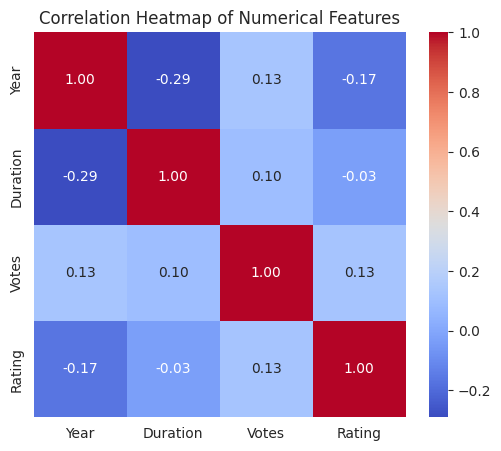

In [20]:
numeric_cols = ["Year", "Duration", "Votes", "Rating"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### 7.6 Duration vs Rating



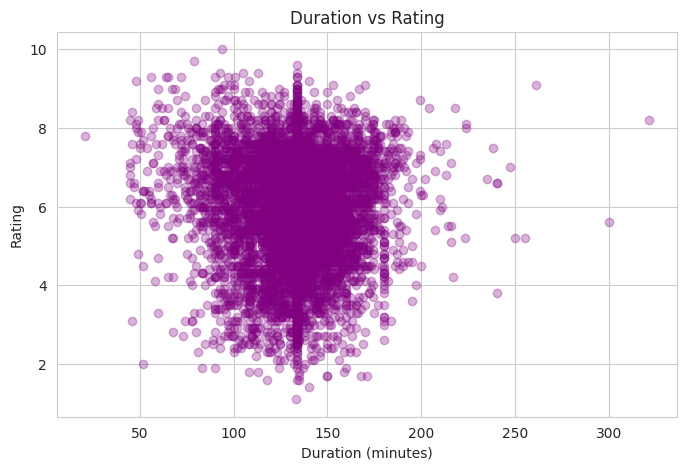

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Duration"], df["Rating"], alpha=0.3, color="purple")
plt.title("Duration vs Rating")
plt.xlabel("Duration (minutes)")
plt.ylabel("Rating")
plt.show()

## 8. Feature Engineering



### 8.1 Handle Multiple Genres and Frequency-Encode Genre



In [22]:
# Step 1: Compute how often each individual genre appears
genre_counts = df["Genre"].str.split(", ").explode().value_counts()

# Step 2: For each movie, average the frequency of all its genres
def encode_genre(genre_string):
    genres = genre_string.split(", ")
    scores = [genre_counts.get(g, 0) for g in genres]
    return np.mean(scores)

df["Genre_Encoded"] = df["Genre"].apply(encode_genre)

df[["Genre", "Genre_Encoded"]].head()

,Genre,Genre_Encoded
1,Drama,4924.000000
3,"Comedy, Romance",1695.000000
5,"Comedy, Drama, Musical",2343.666667
6,"Drama, Romance, War",2246.333333
8,"Horror, Mystery, Thriller",508.666667


### 8.2 Frequency-Encode Director and Actors



In [23]:
def frequency_encode(dataframe, column, new_column):
    freq = dataframe[column].value_counts()
    dataframe[new_column] = dataframe[column].map(freq)
    return dataframe

df = frequency_encode(df, "Director", "Director_Encoded")
df = frequency_encode(df, "Actor 1", "Actor1_Encoded")
df = frequency_encode(df, "Actor 2", "Actor2_Encoded")
df = frequency_encode(df, "Actor 3", "Actor3_Encoded")

df[["Director", "Director_Encoded", "Actor 1", "Actor1_Encoded"]].head()

,Director,Director_Encoded,Actor 1,Actor1_Encoded
1,Gaurav Bakshi,1,Rasika Dugal,2
3,Ovais Khan,1,Prateik,5
5,Rahul Rawail,17,Bobby Deol,18
6,Shoojit Sircar,7,Jimmy Sheirgill,25
8,Allyson Patel,1,Yash Dave,1


## 9. Feature Selection



In [24]:
feature_columns = [
    "Year", "Duration", "Votes",
    "Genre_Encoded", "Director_Encoded",
    "Actor1_Encoded", "Actor2_Encoded", "Actor3_Encoded",
]

X = df[feature_columns]
y = df["Rating"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
X.head()

Feature matrix shape: (7919, 8)
Target vector shape: (7919,)


,Year,Duration,Votes,Genre_Encoded,Director_Encoded,Actor1_Encoded,Actor2_Encoded,Actor3_Encoded
1,2019,109.0,8,4924.000000,1,2,1,1
3,2019,110.0,35,1695.000000,1,5,1,2
5,1997,147.0,827,2343.666667,17,18,15,13
6,2005,142.0,1086,2246.333333,7,25,4,8
8,2012,82.0,326,508.666667,1,1,6,1


## 10. Split the Dataset into Training and Testing Sets



In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} movies")
print(f"Testing set:  {X_test.shape[0]} movies")

Training set: 6335 movies
Testing set:  1584 movies


## 11. Train Multiple Regression Models



In [26]:
# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)

# 3. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

print("All three models have been trained successfully.")

All three models have been trained successfully.


## 12. Compare All Models



In [27]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    return {"R2 Score": r2, "MAE": mae, "MSE": mse, "RMSE": rmse}


results = {
    "Linear Regression": evaluate_model(lr_model, X_test, y_test),
    "Decision Tree": evaluate_model(dt_model, X_test, y_test),
    "Random Forest": evaluate_model(rf_model, X_test, y_test),
}

results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
results_df

,R2 Score,MAE,MSE,RMSE
Linear Regression,0.1128,1.0266,1.6494,1.2843
Decision Tree,0.2670,0.8948,1.3627,1.1673
Random Forest,0.3552,0.8322,1.1987,1.0949


### 12.1 Visualize Model Comparison



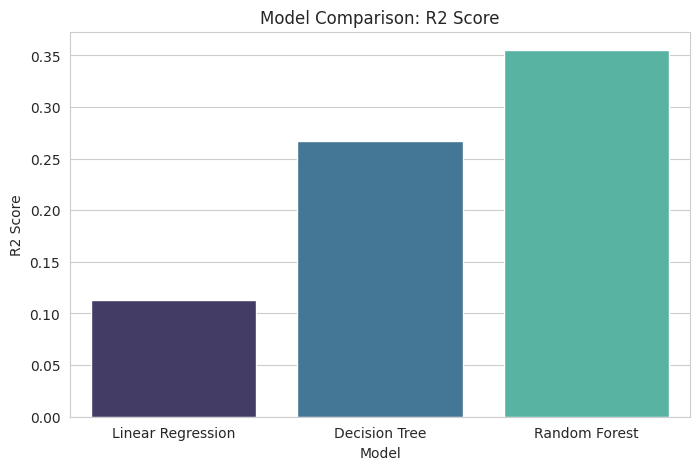

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(x=results_df.index, y=results_df["R2 Score"], hue=results_df.index,
            palette="mako", legend=False)
plt.title("Model Comparison: R2 Score")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.show()

## 13. Select the Best-Performing Model



In [29]:

best_model_name = results_df["R2 Score"].idxmax()

model_lookup = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
}

best_model = model_lookup[best_model_name]

print(f"Best performing model: {best_model_name}")
print(f"R2 Score: {results_df.loc[best_model_name, 'R2 Score']}")

Best performing model: Random Forest
R2 Score: 0.3552


## 14. Predict Movie Ratings Using the Test Data



In [30]:
y_pred = best_model.predict(X_test)

print("Sample predictions:")
print(np.round(y_pred[:10], 2))

Sample predictions:
[4.49 4.93 5.17 5.74 5.72 5.58 4.67 7.07 5.72 5.94]


## 15. Display Actual vs Predicted Ratings



In [ ]:
comparison_df = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": np.round(y_pred, 2),
})
comparison_df["Difference"] = np.round(
    comparison_df["Actual Rating"] - comparison_df["Predicted Rating"], 2
)

comparison_df.head(15)

,Actual Rating,Predicted Rating,Difference
0,3.3,4.49,-1.19
1,5.3,4.93,0.37
2,5.7,5.17,0.53
3,7.2,5.74,1.46
4,3.5,5.72,-2.22
5,7.2,5.58,1.62
6,3.8,4.67,-0.87
7,6.9,7.07,-0.17
8,5.2,5.72,-0.52
9,7.4,5.94,1.46


## 16. Plot Prediction Results

### 16.1 Actual vs Predicted Scatter Plot



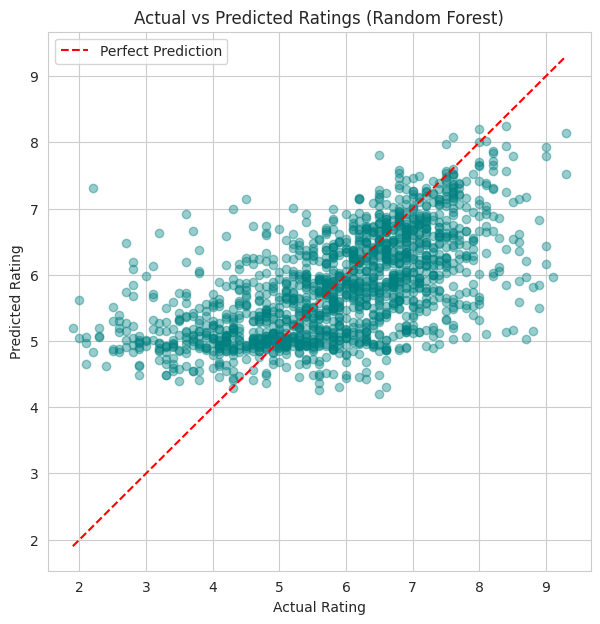

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linestyle="--", label="Perfect Prediction")
plt.title(f"Actual vs Predicted Ratings ({best_model_name})")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.legend()
plt.show()

### 16.2 Residual Plot



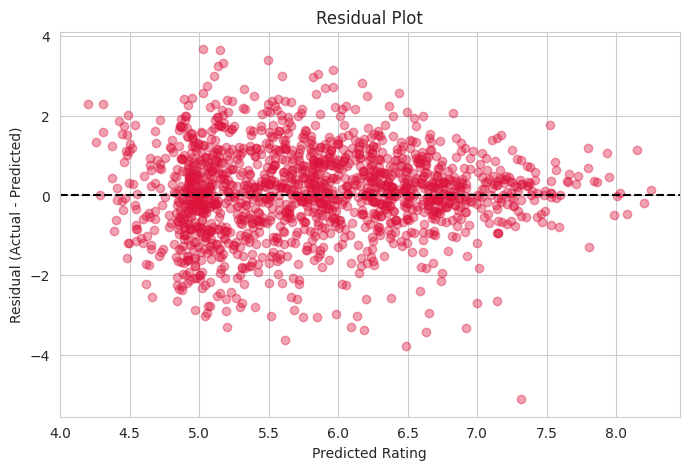

In [ ]:
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.4, color="crimson")
plt.axhline(y=0, color="black", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted Rating")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()

## 17. Feature Importance



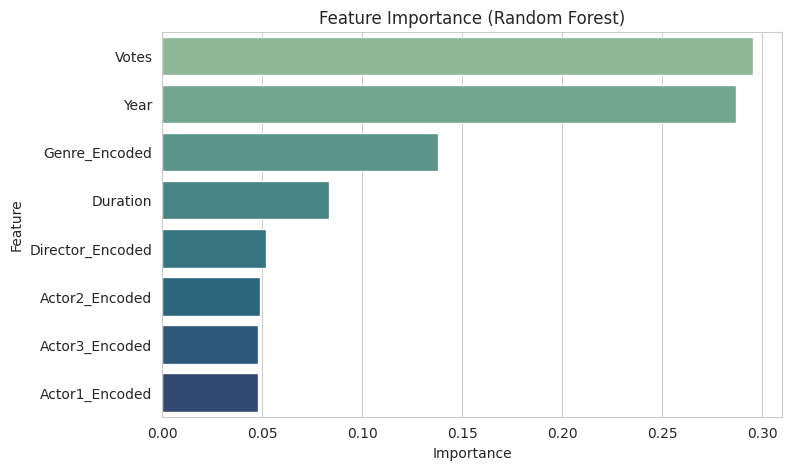

In [ ]:
if hasattr(best_model, "feature_importances_"):
    # Decision Tree / Random Forest
    importances = pd.Series(best_model.feature_importances_, index=feature_columns)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
                palette="crest", legend=False)
    plt.title(f"Feature Importance ({best_model_name})")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

elif hasattr(best_model, "coef_"):
    # Linear Regression
    coefficients = pd.Series(best_model.coef_, index=feature_columns)
    coefficients = coefficients.sort_values()

    plt.figure(figsize=(8, 5))
    sns.barplot(x=coefficients.values, y=coefficients.index, hue=coefficients.index,
                palette="crest", legend=False)
    plt.title(f"Feature Coefficients ({best_model_name})")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Feature")
    plt.show()

## 18. Save the Trained Model



In [ ]:
import os

os.makedirs("models", exist_ok=True)
model_path = "models/best_model.pkl"

joblib.dump(best_model, model_path)

print(f"Model '{best_model_name}' saved to: {model_path}")

Model 'Random Forest' saved to: models/best_model.pkl


## 19. Save Predictions into a CSV File



In [ ]:
os.makedirs("outputs", exist_ok=True)
predictions_path = "outputs/predictions.csv"

comparison_df.to_csv(predictions_path, index=False)

print(f"Predictions saved to: {predictions_path}")

Predictions saved to: outputs/predictions.csv


In [ ]:
files.download("outputs/predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls models/

best_model.pkl


In [ ]:
from google.colab import files
files.download("models/best_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>